# 2026 Predictions
## Goal
Build the 2026 AUS GP input dataframe and generate podium probability estimates per driver.

## Approach
- Use 2023-2025 historical data to calculate driver and constructor features
- GridPosition will be updated after March 7 qualifying
- Generate probability estimates using calibrated Random Forest model

## Input
- aus_gp_features.csv 
- calibrated_rf_model.pkl (trained model)

## Output
- 2026 podium probability estimates per driver
- Final predictions ready for publishing

## Note on GridPosition
Qualifying hasn't happened yet. We use placeholder grid positionsbased on 2025 end of season performance. These will be updated with real qualifying results before publishing.

# Core Libraries and Load Model

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline

# Load calibrated model and feature columns
with open('calibrated_rf_model.pkl', 'rb') as f:
    calibrated_model = pickle.load(f)

with open('feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)

print("Model loaded successfully!")
print("Expected features:", feature_columns)

Model loaded successfully!
Expected features: ['GridPosition', 'driver_aus_podium_rate', 'constructor_aus_podium_rate']


#  Load historical data to calculate features

In [2]:
# Load historical data to calculate driver and constructor podium rates
df_hist = pd.read_csv('aus_gp_features.csv')

# Calculate driver historical AUS GP podium rate (2023-2025)
driver_podium_rate = df_hist.groupby('Abbreviation')['Podium'].mean().reset_index()
driver_podium_rate.columns = ['Abbreviation', 'driver_aus_podium_rate']

# Calculate constructor historical AUS GP podium rate (2023-2025)
constructor_podium_rate = df_hist.groupby('TeamName')['Podium'].mean().reset_index()
constructor_podium_rate.columns = ['TeamName', 'constructor_aus_podium_rate']

print("Driver podium rates:")
print(driver_podium_rate.sort_values('driver_aus_podium_rate', ascending=False).head(10))

Driver podium rates:
   Abbreviation  driver_aus_podium_rate
15          NOR                0.666667
25          VER                0.666667
1           ALO                0.333333
13          LEC                0.333333
20          RUS                0.333333
10          HAM                0.333333
21          SAI                0.333333
2           ANT                0.000000
3           BEA                0.000000
5           BOT                0.000000


# 2026 driver lineup

In [4]:
# 2026 F1 driver lineup - confirmed
# GridPosition is placeholder based on 2025 form - updated after qualifying
drivers_2026 = pd.DataFrame({
    'Abbreviation': ['VER', 'HAD', 'LEC', 'HAM', 'NOR', 'PIA',
                     'RUS', 'ANT', 'ALO', 'STR',
                     'GAS', 'COL', 'LAW', 'LIN',
                     'HUL', 'BOR', 'ALB', 'SAI',
                     'OCO', 'BEA', 'PER', 'BOT'],
    'TeamName': ['Red Bull Racing', 'Red Bull Racing', 'Ferrari', 'Ferrari',
                 'McLaren', 'McLaren', 'Mercedes', 'Mercedes',
                 'Aston Martin', 'Aston Martin', 'Alpine', 'Alpine',
                 'Racing Bulls', 'Racing Bulls', 'Audi', 'Audi',
                 'Williams', 'Williams', 'Haas F1 Team', 'Haas F1 Team',
                 'Cadillac', 'Cadillac'],
    'GridPosition': [1, 18, 3, 4, 2, 8, 5, 11, 9, 15,
                     13, 17, 14, 20, 10, 19, 7, 6, 16, 12, 21, 22]
})

print(drivers_2026)
print("\nTotal drivers:", len(drivers_2026))

   Abbreviation         TeamName  GridPosition
0           VER  Red Bull Racing             1
1           HAD  Red Bull Racing            18
2           LEC          Ferrari             3
3           HAM          Ferrari             4
4           NOR          McLaren             2
5           PIA          McLaren             8
6           RUS         Mercedes             5
7           ANT         Mercedes            11
8           ALO     Aston Martin             9
9           STR     Aston Martin            15
10          GAS           Alpine            13
11          COL           Alpine            17
12          LAW     Racing Bulls            14
13          LIN     Racing Bulls            20
14          HUL             Audi            10
15          BOR             Audi            19
16          ALB         Williams             7
17          SAI         Williams             6
18          OCO     Haas F1 Team            16
19          BEA     Haas F1 Team            12
20          P

# Merge historical features onto 2026 lineup

In [5]:
# Merge driver historical podium rate
drivers_2026 = drivers_2026.merge(driver_podium_rate, on='Abbreviation', how='left')

# Merge constructor historical podium rate
drivers_2026 = drivers_2026.merge(constructor_podium_rate, on='TeamName', how='left')

# Fill 0.0 for new drivers and constructors with no AUS history
drivers_2026['driver_aus_podium_rate'] = drivers_2026['driver_aus_podium_rate'].fillna(0.0)
drivers_2026['constructor_aus_podium_rate'] = drivers_2026['constructor_aus_podium_rate'].fillna(0.0)

print(drivers_2026[['Abbreviation', 'TeamName', 'GridPosition', 
                     'driver_aus_podium_rate', 'constructor_aus_podium_rate']])

   Abbreviation         TeamName  GridPosition  driver_aus_podium_rate  \
0           VER  Red Bull Racing             1                0.666667   
1           HAD  Red Bull Racing            18                0.000000   
2           LEC          Ferrari             3                0.333333   
3           HAM          Ferrari             4                0.333333   
4           NOR          McLaren             2                0.666667   
5           PIA          McLaren             8                0.000000   
6           RUS         Mercedes             5                0.333333   
7           ANT         Mercedes            11                0.000000   
8           ALO     Aston Martin             9                0.333333   
9           STR     Aston Martin            15                0.000000   
10          GAS           Alpine            13                0.000000   
11          COL           Alpine            17                0.000000   
12          LAW     Racing Bulls      

# Generate predictions

In [6]:
# Generate podium probability predictions
X_2026 = drivers_2026[feature_columns]
drivers_2026['podium_probability'] = calibrated_model.predict_proba(X_2026)[:, 1]

# Sort by probability
predictions = drivers_2026[['Abbreviation', 'TeamName', 'GridPosition', 
                             'podium_probability']].sort_values(
                             'podium_probability', ascending=False).round(3)

print("2026 AUS GP Podium Predictions (placeholder grid positions):")
print(predictions)

2026 AUS GP Podium Predictions (placeholder grid positions):
   Abbreviation         TeamName  GridPosition  podium_probability
3           HAM          Ferrari             4               0.933
2           LEC          Ferrari             3               0.804
0           VER  Red Bull Racing             1               0.713
4           NOR          McLaren             2               0.696
6           RUS         Mercedes             5               0.114
17          SAI         Williams             6               0.016
5           PIA          McLaren             8               0.000
1           HAD  Red Bull Racing            18               0.000
8           ALO     Aston Martin             9               0.000
7           ANT         Mercedes            11               0.000
10          GAS           Alpine            13               0.000
11          COL           Alpine            17               0.000
12          LAW     Racing Bulls            14               0.000
9

# Visualization

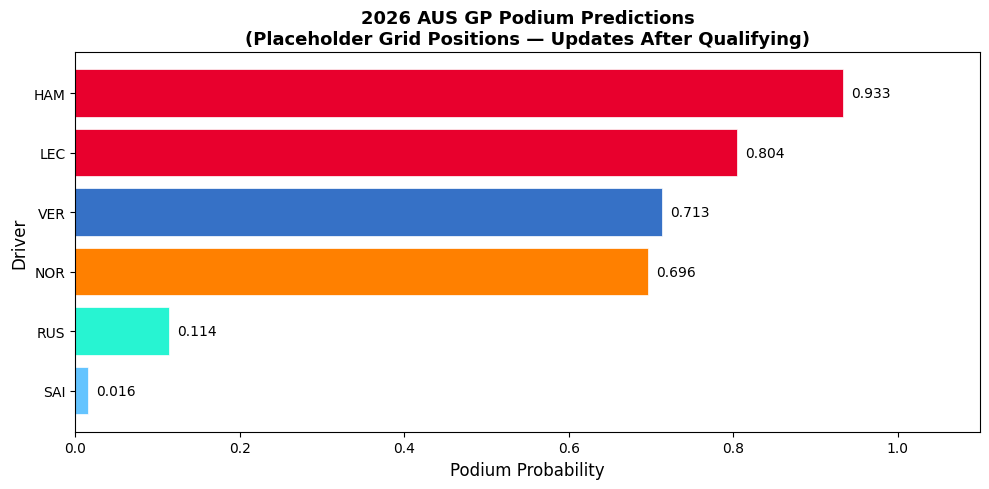

In [10]:
# Only show drivers with non-zero probabilities
predictions_filtered = predictions[predictions['podium_probability'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))

team_colors = {
    'Red Bull Racing': '#3671C6',
    'Ferrari': '#E8002D',
    'McLaren': '#FF8000',
    'Mercedes': '#27F4D2',
    'Aston Martin': '#229971',
    'Alpine': '#FF87BC',
    'Racing Bulls': '#6692FF',
    'Audi': '#C8C8C8',
    'Williams': '#64C4FF',
    'Haas F1 Team': '#B6BABD',
    'Cadillac': '#C00000'
}

colors = [team_colors.get(team, '#888888') for team in predictions_filtered['TeamName']]

bars = ax.barh(predictions_filtered['Abbreviation'],
               predictions_filtered['podium_probability'],
               color=colors, edgecolor='white', linewidth=0.5)

for bar, prob in zip(bars, predictions_filtered['podium_probability']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{prob:.3f}', va='center', fontsize=10)

ax.set_xlabel('Podium Probability', fontsize=12)
ax.set_ylabel('Driver', fontsize=12)
ax.set_title('2026 AUS GP Podium Predictions\n(Placeholder Grid Positions — Updates After Qualifying)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('2026_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Save predictions to CSV

In [11]:
drivers_2026.to_csv('2026_predictions.csv', index=False)
print("Predictions saved!")
print("\nTop predictions:")
print(predictions_filtered[['Abbreviation', 'TeamName', 'GridPosition', 
                             'podium_probability']])

Predictions saved!

Top predictions:
   Abbreviation         TeamName  GridPosition  podium_probability
3           HAM          Ferrari             4               0.933
2           LEC          Ferrari             3               0.804
0           VER  Red Bull Racing             1               0.713
4           NOR          McLaren             2               0.696
6           RUS         Mercedes             5               0.114
17          SAI         Williams             6               0.016
